**Introduction to Artificial Intelligence Lab 1B**<br>
Part 1: Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Part 2: Foundations from Part A

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False

In [5]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        if state == self.goal:
          return True
        else:
          return False

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        row,col =state
        legal_actions=[]
        if self.in_bounds((row-1,col)) and self.is_free((row-1,col)):
          legal_actions.append("UP")
        if self.in_bounds((row+1,col)) and self.is_free((row+1,col)):
          legal_actions.append("DOWN")
        if self.in_bounds((row,col-1)) and self.is_free((row,col-1)):
          legal_actions.append("LEFT")
        if self.in_bounds((row,col+1)) and self.is_free((row,col+1)):
          legal_actions.append("RIGHT")
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr,dc=MOVES[action]
        return (row+dr,col+dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1.0

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state=node.state
        for action in problem.actions(state):
            s_prime=problem.result(state,action)
            cost=node.path_cost+problem.action_cost(state,action,s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [6]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

Part 3: Weighted Terrain: WeightedGridProblem

In [7]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        row,col=next_state
        return self.terrain_costs[row][col]

Part 3.1: Self-Check for WeightedGridProblem

In [8]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


Part 4.1: Admissibility and Consistency on our Grid

In [9]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1,c1=state
    r2,c2=goal
    return abs(r1-r2)+abs(c1-c2)

def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    r1,c1=state
    r2,c2=goal
    return math.sqrt((r1-r2)**2+(c1-c2)**2)

def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0


Part 4.2: Self-Check for the Heuristics

In [10]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


Part 5: The Priority-Queue Frontier (Provided)

In [11]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

Part 6: The BestFirstSearch Framework

In [12]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        node=Node(problem.initial_state())
        frontier=PriorityQueue()
        frontier.push(self.evaluation(node,problem),node)
        total_nodesexpanded=0
        maximum_frontier_size=1
        reached={problem.initial_state():node}

        while len(frontier)>0:
            node=frontier.pop()
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=total_nodesexpanded,
                    max_frontier_size=maximum_frontier_size,
                    reached_count=len(reached)
                )
            total_nodesexpanded+=1
            for child in self.expand(problem, node):
                s=child.state
                if s not in reached or child.path_cost<reached[s].path_cost:
                    reached[s]=child
                    frontier.push(self.evaluation(child,problem),child)
            maximum_frontier_size=frontier.__len__()
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=total_nodesexpanded,
            max_frontier_size=maximum_frontier_size,
            reached_count=len(reached)
        )

Part 7: Greedy Best-First Search

In [13]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node, problem)

Part 8: A* Search

In [14]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost+self.h(node,problem)

Part 9: Uniform-Cost as a Special Case (Provided)

In [15]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

Part 10: Weighted A* Search

In [16]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost+self.h(node,problem)*self.weight

Part 10.1: Self-Check for the Algorithms

In [17]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


Part 11: Run the Algorithms on the Part A Sample Map

In [18]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18.0,52,4,56
1,A*,success,18,18.0,18,5,23
2,Weighted A* (W=2),success,18,18.0,18,5,23
3,Greedy,success,18,18.0,18,5,23


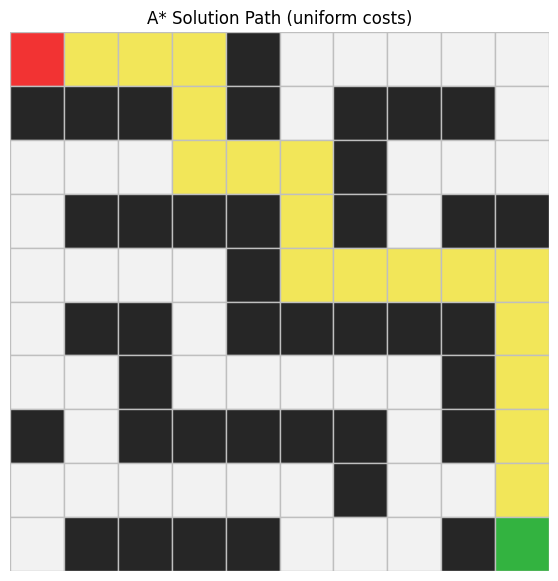

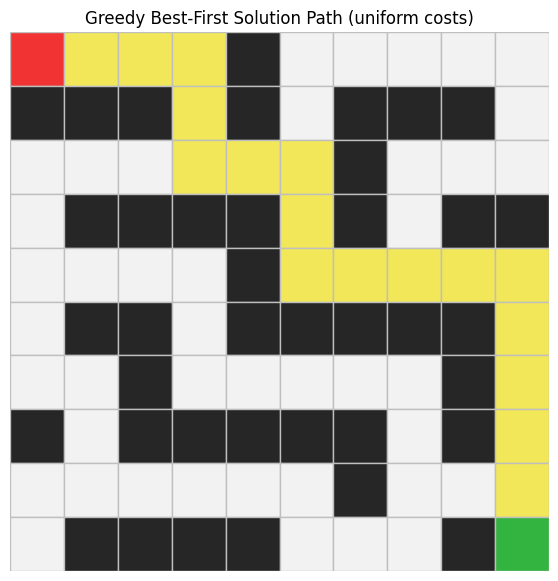

In [19]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

Part 12: The Turbulence Map: Where Greedy Goes Wrong

In [20]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,9,35
1,A*,success,10,10,25,9,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


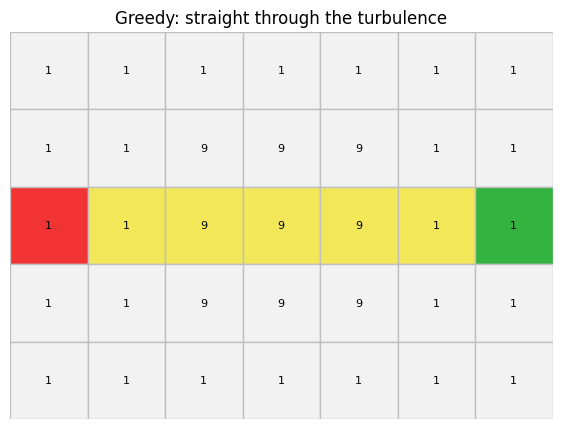

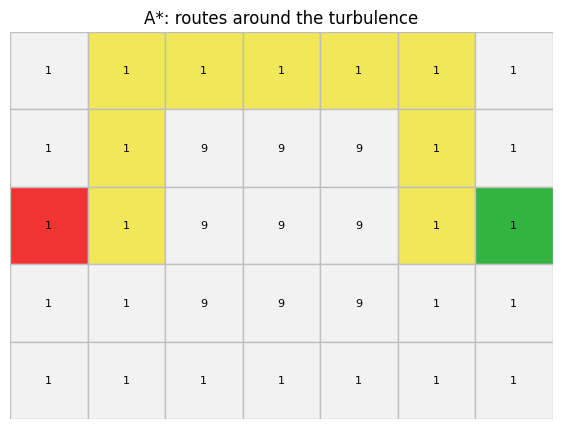

In [21]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

Part 13: Experiment: Breaking Admissibility

In [22]:
def inflated_heuristic(factor: float):
    def h(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
        return factor * manhattan_distance(state, goal)
    return h

# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,6,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


**Record your observations in a markdown cell here:**<br>
On which map(s) did the inflated heuristic return a suboptimal path?<br>By how much?
How many fewer nodes did it expand?<br>
In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?<br>
<br>
Your answer:
The inflated heuristic returned a suboptimal path on the map with mild turbulence. The path was suboptimal by a cost difference of 2. It expanded 23 fewer nodes. If I was to be a drone's engineer, I would accept an inadmissibe heuristic when I would want my drone to be more decisive; when there are cases where delay affects performance measure(semi-dynamic environment) since it handles tie breakers better.

Part 14: Bonus (Optional): Iterative-Deepening A* (IDA*)

In [23]:
class IDAStarSearch(SearchAlgorithm):
      algorithm_name = "IDA*"
      astar=AStarSearch()
      metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }
      def __init__(self, heuristic):
          self.heuristic = heuristic

      def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
          node=Node(problem.initial_state())
          limit=astar.h(node,problem)
          while True:
              result,next_limit=self.f_limited_search(node,limit,problem)
              if problem.is_goal(result.state):
                  return SearchResult(
                      algorithm=self.algorithm_name,
                      status="success",
                      solution=result,
                      nodes_expanded=self.metrics["nodes_expanded"],
                      max_frontier_size=self.metrics["max_stack_size"],
                      reached_count=0,
                      limit=next_limit,
                  )
              if next_limit==np.inf:
                  return SearchResult(
                      algorithm=self.algorithm_name,
                      status="failure",
                      solution=None,
                      nodes_expanded=self.metrics["nodes_expanded"],
                      max_frontier_size=self.metrics["max_stack_size"],
                      reached_count=0,
                      limit=next_limit,
                  )
              limit=next_limit

      def f_limited_search(
          self,
          node:Node,
          limit:int,
          problem:Problem
          )->Tuple[Optional[Node],float]:
          f=node.path_cost + astar.h(node,problem)
          if f > limit:
              return (None,f)
          if problem.is_goal(node.state):
              return (node,f)
          next_limit=np.inf
          self.metrics["nodes_expanded"]+=1
          for child in self.expand(problem, node):
              s=child.state
              if state_is_on_path(node,s):
                  continue
              self.metrics["max_stack_size"]+=1
              result, new_f = self.f_limited_search(child, limit,problem)
              if result:
                  return (result,new_f)
              next_limit=min(next_limit, new_f)
          return (None,next_limit)

  # After completing the bonus, compare IDA* with A* here:
ida = IDAStarSearch(manhattan_distance)
show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A*,success,18,18.0,18,5,23
1,IDA*,success,18,18.0,18,22,0


Part 15: Create Your Own Maps

In [24]:
custom_grid_1 = [
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
]

custom_costs_1 = [
     [1,1,1,1,4,3,6,6,1,1,1,1,1,1,2,3,3,4,5,1],
     [1,4,1,1,1,2,1,2,4,6,8,1,3,5,7,1,1,1,1,1],
     [1,4,1,1,1,1,1,1,1,1,1,6,1,1,4,1,1,2,1,1],
     [1,4,1,1,1,4,1,1,1,2,1,1,1,2,1,1,1,1,1,1],
     [1,4,1,1,1,1,1,1,1,1,1,1,1,6,6,6,6,6,1,1],
     [1,4,1,1,1,2,1,1,1,2,1,1,1,1,1,1,1,6,1,2],
     [1,4,1,1,1,1,1,1,1,2,1,1,1,6,6,6,6,6,1,1],
     [1,4,1,1,4,1,1,1,1,1,1,1,2,1,1,1,1,1,1,5],
     [5,4,1,1,1,1,4,1,5,1,6,1,1,1,1,6,1,1,1,1],
     [1,1,1,1,1,5,1,1,7,1,1,1,1,2,1,1,1,2,1,1],
     [1,1,6,1,1,1,6,1,1,1,6,1,1,1,6,1,1,1,6,1],
     [1,2,3,4,5,6,7,8,9,1,2,3,4,5,6,7,8,9,1,1],
     [1,2,1,1,2,1,1,1,2,2,1,1,1,2,1,1,1,2,1,1],
     [1,1,2,1,1,1,1,1,2,1,1,1,2,6,1,1,4,1,1,1],
     [1,1,1,7,1,1,4,1,7,3,1,1,1,1,1,1,1,1,2,1],
     [2,4,1,1,1,1,1,1,4,1,7,1,1,1,1,1,1,1,1,1],
     [1,1,2,2,3,3,4,4,5,5,6,6,1,1,2,2,1,1,1,1],
     [1,2,1,2,1,2,1,2,1,2,1,2,1,2,1,2,1,2,1,2],
     [1,1,2,2,5,1,1,1,1,1,1,1,10,1,1,1,1,1,1,1],
     [1,1,1,2,1,6,1,7,7,7,7,1,1,1,1,1,1,1,1,1],
]

custom_start_1 = (3,3)
custom_goal_1 = (19,19)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,32,33,396,4,400
1,A*,success,32,33,137,89,217
2,Weighted A* (W=2),success,32,39,39,57,95
3,Greedy,success,32,74,32,49,81


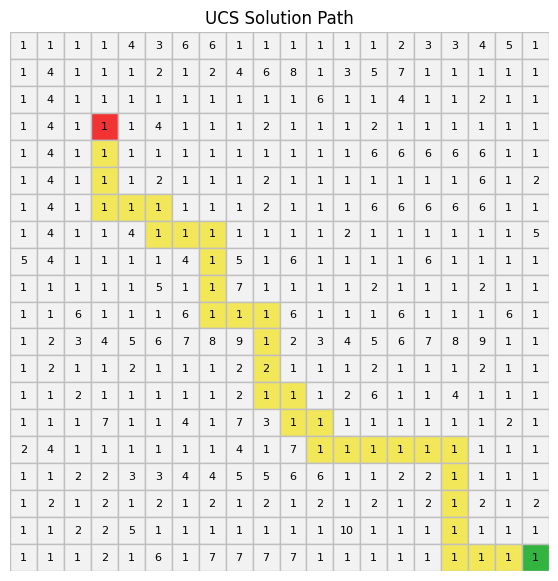

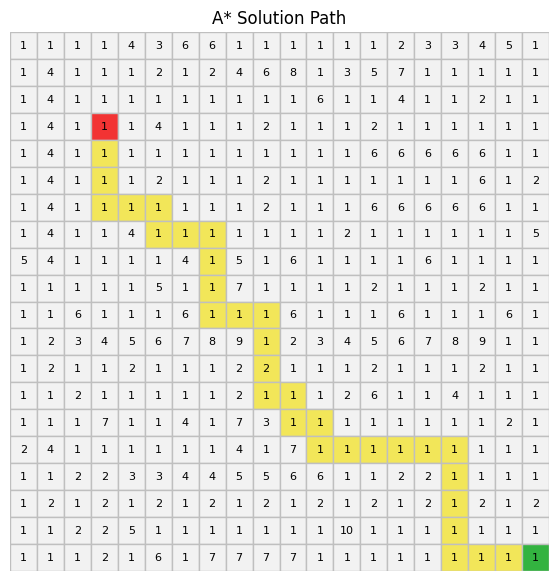

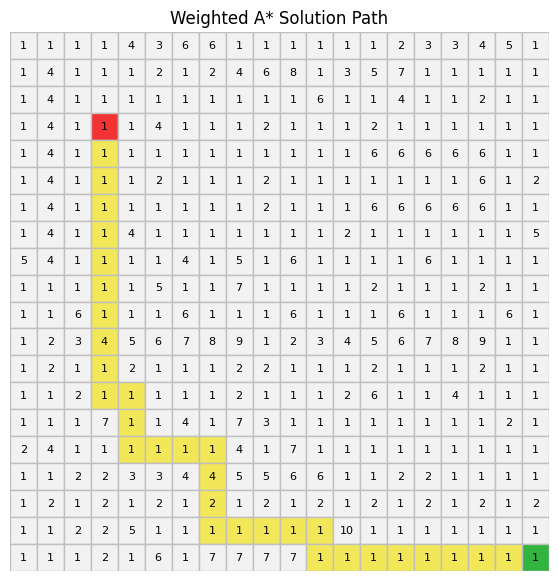

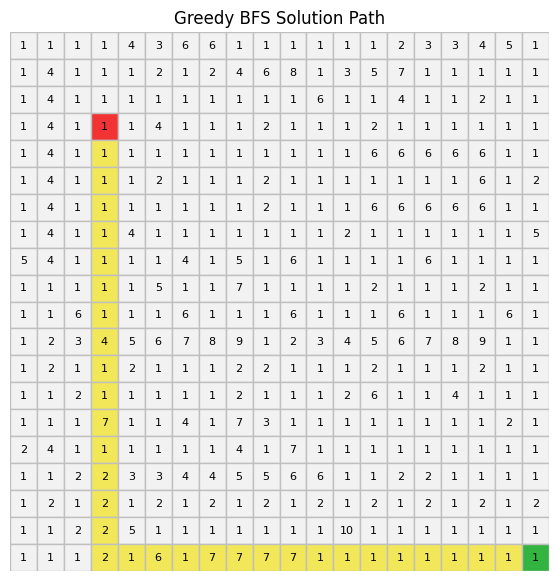

In [25]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    terrain_costs=custom_costs_1,
    title="UCS Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="A* Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[2].path,
    terrain_costs=custom_costs_1,
    title="Weighted A* Solution Path",
)
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="Greedy BFS Solution Path",
)

**Write a short interpretation (2–4 sentences): which algorithm "won", and on which metric?**<br>
For this map, UCS and A* search "won"; both their solution paths are identical, but A* used more memory having a much higher frontier size. A* however expanded fewer nodes, so the situation implies a tradeoff exists between the two.

In [26]:
custom_grid_2 = [
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
     [0,0,0,0,0,0,0,0,0,0,0,0],
]

custom_costs_2 = [
     [1,1,2,1,1,1,1,1,1,8,8,1],
     [1,1,1,1,1,3,1,1,1,8,8,1],
     [1,2,3,1,1,7,1,1,1,8,8,1],
     [4,5,6,7,2,1,1,1,1,1,2,1],
     [1,1,2,3,1,1,2,3,4,5,1,1],
     [1,7,6,5,4,3,2,1,1,1,2,1],
     [1,4,6,9,1,1,1,1,1,1,1,1],
     [2,2,2,1,1,3,1,1,1,5,1,1],
     [1,7,5,3,1,1,2,1,1,3,1,1],
     [6,6,6,6,1,1,1,1,1,3,4,1],
     [1,1,1,1,1,6,6,6,1,1,1,1],
     [10,1,1,1,1,1,1,6,1,1,1,1],
]

custom_start_2 = (0,0)
custom_goal_2 = (11,11)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,22,24,134,10,144
1,A*,success,22,24,47,28,69
2,Weighted A* (W=2),success,22,25,23,29,52
3,Greedy,success,22,45,22,21,43


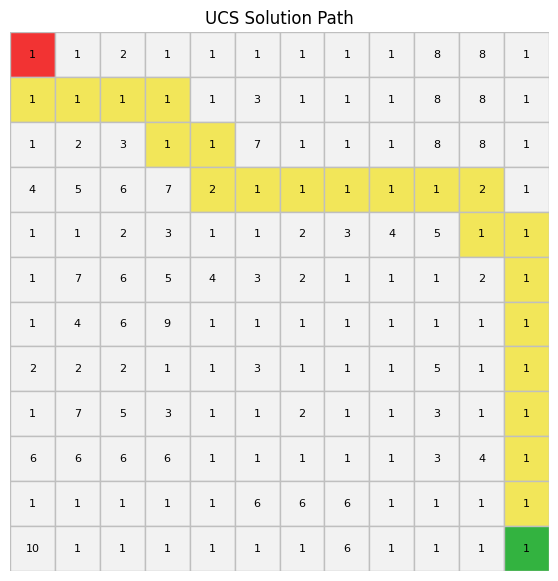

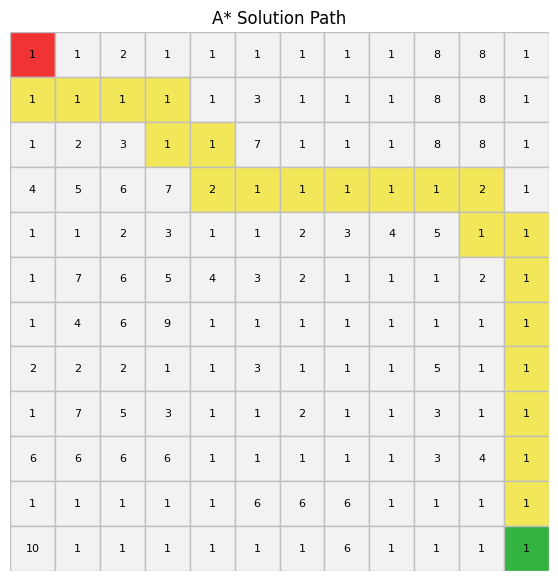

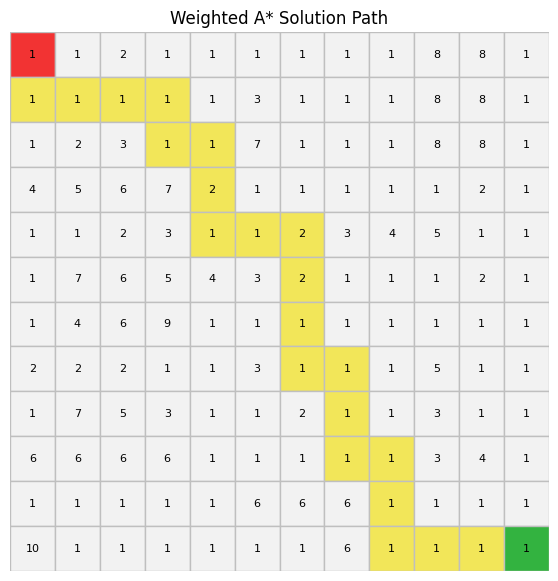

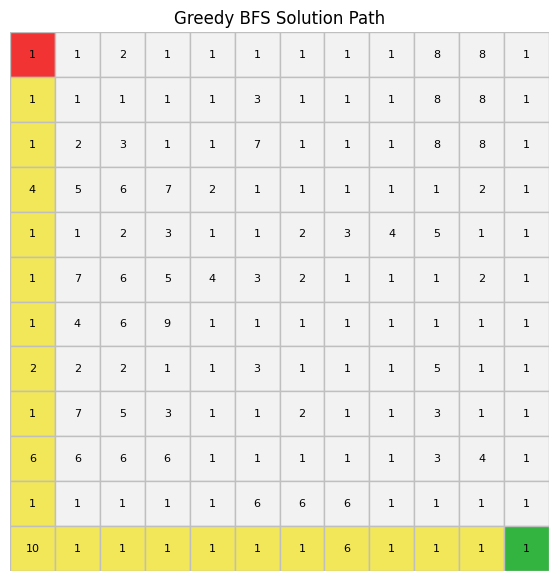

In [27]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    terrain_costs=custom_costs_2,
    title="UCS Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    terrain_costs=custom_costs_2,
    title="A* Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="Weighted A* Solution Path",
)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy BFS Solution Path",
)

**Write a short interpretation (2–4 sentences): which algorithm "won", and on which metric?**<br>
For this map, UCS and A* search "won" in terms of solution cost, but Weighted A* showed less nodes expanded and frontier dependence; so I would opt for Weighted A* even though it increases my solution cost by one unit.

__Part 16: Reflection Questions__<br>
Checkpoint questions (answer in Section 16): What were the two solution costs? Did A* expand more nodes than Greedy here? Why is "Greedy expanded fewer nodes" not the same claim as "Greedy is the better algorithm"?<br>
The two solution costs were 30 for Greedy BFS and 10 for A*. A* expanded more nodes than the Greedy BFS(6 vs 25) as well. Greedy BFS can only be said to expand fewer nodes but not be better than A*; this is because Greedy BFS does not consider the cost already incurred, even though it is more direct. This makes it use costlier paths more often, and makes it worse. The claim is therefore invalid.<br>
<br>
IDA* uses linear memory but may re-expand nodes many times — measure both and compare with A* in your reflection.<br>
From my results, they both had similar stats, except that IDA used more memory in the maximum frontier length; it however had reached no states, which could explain the observation from the prompt.
<br>
<br>
**16.1 Heuristic Functions**<br>
**1.In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?**<br>
I think that the Heuristic function(h(n)) estimates the cost of getting to the goal state from the current node. This knowledge comes from the experience of seeing the flaws of the Greedy BFS as compared to the A* algorithm and seeing that it is not enough to find a path of minimal cost.<br>
**2.Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?**<br>
It removes the excessive complexity of considering all variation in possible cost paths by making them discretized. It also removes the restriction of memory that would otherwise compute solutions based on infinitesimally small movements.<br>
**3.Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?**<br>
In this case, Manhattan distance dominates, since information is discretized and Manhattan distance is better suited to account for this. Manhattan distance is also a larger admissible heuristic, so that further suggests to me that it dominates. I predict that Euclidean distance will expand more nodes than the value of the distance, since obstacles and grid restrictions were not considered. Manhattan distance, will however be on point.<br>
**4.Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?**<br>
This is because the sum of action costs along the sum of vertical and horizontal actions will result in a bigger value than the latter sum(Manhattan distance) since all costs are greater or equal to the terrain cost. But if terrain cost is 0.5, there is a possibility that the sum can be less than the Manhattan distance. This would not make it admissible.<br>
<br>
**16.2 Greedy Best-First Search**<br>
**1.Which quantity does Greedy ignore, and how did the turbulence map punish it for that?**<br>
The Greedy Best-First Search ignored the cost already incurred to get to the current node, and it was punished for that in the turbulence map by going right through the turbulence.<br>
__2.Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?__<br>
This is because Greedy BFS does not consider the cost already incurred, even though it is more direct. This makes it use costlier paths more often, and makes it worse. So it cannot be concluded to be the better algorithm only because it expanded fewer nodes. This is also the case where the graph is weighted, so it would neglect that.<br>
__3.Describe a drone mission where Greedy's behaviour would actually be acceptable.__<br>
Greedy's behaviour would be acceptable in the case where priority is on minimization of run-time and reduction of tie breaker states.<br>
<br>
__16.3 A* Search__<br>
__1.Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.__<br>
A drone's flight plan subscribing to f(n)=g(n)+h(n) means that it considers the cost of going from its starting point to the goal state through n. It considers the cost so far and chooses the next set of nodes that minimize both that and the cost to the goal state.<br>
__2.Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?__<br>
A* must apply the goal test when a node is popped rather than when it is generated because if the node that is generated is popped first, there could be a node that results in a cheaper path from the start that would be in the frontier, but it would be ignored. An early goal test on the turbulence map could ignore other solutions with differing sometimes cheaper solution costs.<br>
__3.Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?__<br>
The reached set needs to be a dictionary here because should the search algorithms find a more optimal path with regards to cost, it would have to overwrite its reached set, which a dictionary allows. A set was enough in Part A because it was Uniform Cost search, so there was no need to consider the possibility of a cheaper cost being available.<br>
__4.Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?__<br>
The A* algorithm expands less nodes than UCS on all maps in this file. This gap informs me that the heuristic prevents expansion of unnecessary nodes; knowing the distance between current state and the goal state allows to search that distance for all possible paths(limiting the depth needed to search), which is better than searching the full scope of the environment.<br>
<br>
__16.4 Admissibility and Consistency__<br>
__1.State the definitions of admissible and consistent. Which implies which?__<br>
An admissible graph is one whose heuristic never overestimates the remaining cost. A consistent graph is one that satisfies the triangle equality: where the heuristic to a node never overestimates the cost of moving from one node to another and the heuristic of the other node.Every consistent graph is admissible, but the converse is not true.<br>
__2.What did your inadmissible-heuristic experiment show about the lecture's optimality claim?__<br>
It showed that the inadmissible heuristic returned a suboptimal path. It expands fewer nodes, but the increased solution cost connotes the suboptimality the lecture claimed.<br>
__3.Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.__<br>
Manhattan distance is consistent. It considers the cost of all actions 1, and that would imply that for k actions h(n)≤k+h(n'), and the cost from there to the goal (h(n'))would also decrease by that same amount, since it has that number less of steps to take.<br>
<br>
__16.5 Weighted A* and Trade-offs__<br>
__1.How does the weight W interpolate between UCS, A*, and Greedy?__<br>
The weight interpolates between UCS,A* and Greedy by making A* behave more greedy in nature. This also makes it expand less nodes, making it less like UCS. UCS and A* are closely related, and so making the Weighted A* weighted makes it more greedy and less uniform.<br>
__2.What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?__<br>
It guarantees that the cost is at most w times less optimal, and my experiments stayed within that bound; none of the solution costs were more than w times that of the A* algorithm.<br>
__3.The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?__<br>
I would choose an algorithm that prioritizes speed and has a lower number of nodes expanded. I would choose the Weighted A* search algorithm, since it offers some optimality and guarantees suboptimality to be limited; it also acts greedy so handles tie breakers better. The weight I would use would be a high weight(10-15), since I can't be too A*-like; the flight computer is slow so I can't be expanding too many nodes.<br>
<br>
__16.6 Memory and Real-World Drone Context__<br>
__1.Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?__<br>
The A* algorithm uses a priority queue, and this makes it memory hungry because the priorities for each entry have to be both stored and used in popping. The IDA* algorithm uses recursivity, implying the implicit action of some internal stack; this reduces the memory needed, but requires more computational complexity.<br>
__2.In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?__<br>
I could make the terrain costs vary with time, or have some variation patterns.<br>
__3.Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?__<br>
The goal state moving would break all the algorithms related to Informed search, and the heuristic from the current state would constantly be changing. Hence concepts like dynamic environments show since the state of the environment changes with respect to the user, a concept like informed search would still be used since the movement of the goal state has to be studied to best find a means of approaching it.<br>
__4.Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?__<br>
I would use the Weighted A* algorithm again; and I would reconsider by manipulating the weight of the heuristic should I need more greediness or more optimality;UCS and like searches are similar to A* and are accounted for adjustment for optimality.